## Notebook 2: Cân bằng lớp dữ liệu (SMOTE) & Huấn luyện Mô hình Học sâu / Học máy

---
**Mô tả:**
Trong notebook này, chúng ta sẽ tập trung xử lý mất cân bằng lớp bằng thuật toán **SMOTE** (Synthetic Minority Over-sampling Technique), sau đó huấn luyện và đánh giá song song 4 mô hình: `Logistic Regression`, `Decision Tree`, `Random Forest`, và `1D-CNN (Convolutional Neural Network)` trên cả hai cấu hình: tập dữ liệu gốc (mất cân bằng) và tập dữ liệu cân bằng (SMOTE). Cuối cùng, trực quan hóa so sánh hiệu năng qua đường cong ROC Curve và F1-Score tổng hợp.

---

In [5]:
# Import các thư viện lõi cho quá trình Huấn luyện & Đánh giá
import os
import sys
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, roc_curve, auc, roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

# Cấu hình phong cách biểu đồ thống nhất
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 9)

# Thiết lập Hằng số cố định
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("[LOG] Khai báo các thư viện huấn luyện hoàn tất.")

[LOG] Khai báo các thư viện huấn luyện hoàn tất.


In [6]:
# Nạp dữ liệu đã được tiền xử lý và chuẩn hóa từ Notebook 1
# Tự động phát hiện đường dẫn thích hợp
def find_processed_dir():
    curr = os.path.abspath(os.getcwd())
    for _ in range(5):
        candidate = os.path.join(curr, "data", "processed")
        if os.path.exists(candidate):
            return candidate
        curr = os.path.dirname(curr)
    return "../data/processed"

DATA_DIR = find_processed_dir()

# Fallback sang Google Colab drive path nếu không tìm thấy thư mục cục bộ
if not os.path.exists(DATA_DIR):
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = "/content/drive/MyDrive/Dataset/data/processed"

print(f"[LOG] Bắt đầu nạp dữ liệu từ thư mục '{DATA_DIR}'...")
X_train = pd.read_csv(f"{DATA_DIR}/X_train_scaled.csv")
X_test = pd.read_csv(f"{DATA_DIR}/X_test_scaled.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze("columns").astype(int)
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze("columns").astype(int)

print(f"[LOG] Nạp dữ liệu thành công!")
print(f" - X_train: {X_train.shape[0]:,} dòng, {X_train.shape[1]} đặc trưng")
print(f" - X_test: {X_test.shape[0]:,} dòng, {X_test.shape[1]} đặc trưng")
print(f" - Phân bố nhãn lớp tập Train:\n{y_train.value_counts(normalize=True)*100}")

Mounted at /content/drive
[LOG] Bắt đầu nạp dữ liệu từ thư mục '/content/drive/MyDrive/Dataset/data/processed'...
[LOG] Nạp dữ liệu thành công!
 - X_train: 227,845 dòng, 30 đặc trưng
 - X_test: 56,962 dòng, 30 đặc trưng
 - Phân bố nhãn lớp tập Train:
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64


In [7]:
# Áp dụng thuật toán SMOTE để cân bằng dữ liệu
print("[LOG] Đang thực hiện cân bằng dữ liệu bằng SMOTE...")
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("[LOG] Quá trình sinh mẫu SMOTE hoàn tất!")
print(f" - Kích thước tập Train gốc: {X_train.shape[0]:,} mẫu")
print(f" - Kích thước tập Train sau SMOTE: {X_train_smote.shape[0]:,} mẫu")
print("Phân bố nhãn tập train sau SMOTE:\n", pd.Series(y_train_smote).value_counts())

[LOG] Đang thực hiện cân bằng dữ liệu bằng SMOTE...
[LOG] Quá trình sinh mẫu SMOTE hoàn tất!
 - Kích thước tập Train gốc: 227,845 mẫu
 - Kích thước tập Train sau SMOTE: 454,902 mẫu
Phân bố nhãn tập train sau SMOTE:
 Class
0    227451
1    227451
Name: count, dtype: int64


In [8]:
# Khởi tạo thư mục lưu mô hình
def find_models_dir():
    curr = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.exists(os.path.join(curr, "data")) or os.path.exists(os.path.join(curr, "README.md")):
            models_path = os.path.join(curr, "models")
            os.makedirs(models_path, exist_ok=True)
            return models_path
        curr = os.path.dirname(curr)
    return "../models"

model_dir = find_models_dir()
# Thư mục drive sơ cua cho Colab
if not os.path.exists(model_dir):
    model_dir = '/content/drive/MyDrive/Dataset/models'
os.makedirs(model_dir, exist_ok=True)

# Hàm tạo mô hình mới tránh bị ghi đè trọng số (y hệt DataMining.ipynb)
def get_fresh_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    }

models_no_smote = get_fresh_models()
models_smote = get_fresh_models()

# Dict lưu kết quả phục vụ vẽ biểu đồ
predictions_no_smote = {}
predict_probas_no_smote = {}
predictions = {}
predict_probas = {}

# Huấn luyện và Lưu mô hình: KHÔNG SMOTE (y hệt DataMining.ipynb)
print("--- ĐANG HUẤN LUYỆN: TẬP DỮ LIỆU GỐC (KHÔNG SMOTE) ---")
for name, model in models_no_smote.items():
    model.fit(X_train, y_train)
    predictions_no_smote[name] = model.predict(X_test)
    predict_probas_no_smote[name] = model.predict_proba(X_test)[:, 1]

    # Lưu file .joblib
    save_path = os.path.join(model_dir, f"{name.replace(' ', '')}_NoSMOTE.joblib")
    joblib.dump(model, save_path)
    print(f"   Đã train và lưu: {name} (Gốc) tại '{save_path}'")

# Huấn luyện và Lưu mô hình: CÓ SMOTE (y hệt DataMining.ipynb)
print("\n--- ĐANG HUẤN LUYỆN: TẬP DỮ LIỆU SMOTE ---")
for name, model in models_smote.items():
    model.fit(X_train_smote, y_train_smote)
    predictions[name] = model.predict(X_test)
    predict_probas[name] = model.predict_proba(X_test)[:, 1]

    # Lưu file .joblib
    save_path = os.path.join(model_dir, f"{name.replace(' ', '')}_SMOTE.joblib")
    joblib.dump(model, save_path)
    print(f"   Đã train và lưu: {name} (SMOTE) tại '{save_path}'")

--- ĐANG HUẤN LUYỆN: TẬP DỮ LIỆU GỐC (KHÔNG SMOTE) ---
   Đã train và lưu: Logistic Regression (Gốc) tại '/content/drive/MyDrive/Dataset/models/LogisticRegression_NoSMOTE.joblib'
   Đã train và lưu: Decision Tree (Gốc) tại '/content/drive/MyDrive/Dataset/models/DecisionTree_NoSMOTE.joblib'
   Đã train và lưu: Random Forest (Gốc) tại '/content/drive/MyDrive/Dataset/models/RandomForest_NoSMOTE.joblib'

--- ĐANG HUẤN LUYỆN: TẬP DỮ LIỆU SMOTE ---
   Đã train và lưu: Logistic Regression (SMOTE) tại '/content/drive/MyDrive/Dataset/models/LogisticRegression_SMOTE.joblib'
   Đã train và lưu: Decision Tree (SMOTE) tại '/content/drive/MyDrive/Dataset/models/DecisionTree_SMOTE.joblib'
   Đã train và lưu: Random Forest (SMOTE) tại '/content/drive/MyDrive/Dataset/models/RandomForest_SMOTE.joblib'


**Tập dữ liệu Gốc (Không SMOTE):**
* Mô hình chạy trọn vẹn cả 10 epochs mà không kích hoạt cơ chế dừng sớm.
* Ngay từ Epoch đầu tiên, độ chính xác (Accuracy) đã đạt mức cực kỳ cao (0.9974), và tăng chậm lên 0.9993 ở Epoch cuối.
* Vì tập dữ liệu gốc có tới 99.8% là giao dịch hợp lệ (Normal), mạng CNN chỉ cần dự đoán tất cả mọi giao dịch đưa vào đều là "Hợp lệ" thì nó cũng đã tự động đạt độ chính xác >99%. Loss (độ lỗi) giảm rất chậm chứng tỏ mô hình đang học cách "thiên vị" nhóm đa số một cách an toàn thay vì thực sự tìm ra đặc điểm của giao dịch gian lận.

**Tập dữ liệu CÓ SMOTE:**
* Trái ngược với tập gốc, trên tập SMOTE, quá trình huấn luyện early stop chỉ sau vài epochs.
* Mô hình đạt được độ chính xác trên tập validation (val_accuracy) gần tuyệt đối và val_loss giảm cực mạnh.
* Nhờ thuật toán SMOTE, tỷ lệ giao dịch Hợp lệ và Gian lận lúc này đã là 50:50. Mạng 1D-CNN (với khả năng trích xuất các cụm đặc trưng không gian cục bộ siêu việt nhờ các lớp Tích chập - Convolutional layers) đã nhanh chóng tìm ra được quy luật khác biệt giữa V1-V28 của giao dịch thật và giả. Dữ liệu đã cân bằng ép mô hình phải học đặc trưng thực sự.

In [9]:
# Huấn luyện Mô hình Học sâu 1D-CNN (y hệt DataMining.ipynb)
print("--- ĐANG CHUẨN BỊ DỮ LIỆU CHO 1D-CNN ---")
# 1. Reshape dữ liệu từ 2D (samples, 30) sang 3D (samples, 30, 1) cho CNN
X_train_cnn = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)
X_train_smote_cnn = X_train_smote.values.reshape(X_train_smote.shape[0], X_train_smote.shape[1], 1)

# 2. Hàm thiết kế kiến trúc mạng 1D-CNN
def build_1d_cnn():
    model = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Cài đặt dừng sớm nếu mô hình không cải thiện
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 3. Huấn luyện 1D-CNN (KHÔNG SMOTE)
print("\n--- ĐANG HUẤN LUYỆN 1D-CNN: TẬP DỮ LIỆU GỐC ---")
cnn_no_smote = build_1d_cnn()
cnn_no_smote.fit(X_train_cnn, y_train, epochs=10, batch_size=256,
                 validation_split=0.2, callbacks=[early_stop], verbose=1)

# Dự báo và lưu vào dictionary
pred_probs_cnn_no = cnn_no_smote.predict(X_test_cnn).ravel()
predictions_no_smote["1D-CNN"] = (pred_probs_cnn_no > 0.5).astype(int)
predict_probas_no_smote["1D-CNN"] = pred_probs_cnn_no

# Lưu model (.keras) và trọng số (.weights.h5) để tương thích Streamlit App
cnn_no_smote.save(os.path.join(model_dir, "1D-CNN_NoSMOTE.keras"))
cnn_no_smote.save_weights(os.path.join(model_dir, "1D-CNN_NoSMOTE_weights.weights.h5"))
print(" ✅ Đã train và lưu: 1D-CNN (Gốc)")

# 4. Huấn luyện 1D-CNN (CÓ SMOTE)
print("\n--- ĐANG HUẤN LUYỆN 1D-CNN: TẬP DỮ LIỆU SMOTE ---")
cnn_smote = build_1d_cnn()
cnn_smote.fit(X_train_smote_cnn, y_train_smote, epochs=10, batch_size=256,
              validation_split=0.2, callbacks=[early_stop], verbose=1)

# Dự báo và lưu vào dictionary
pred_probs_cnn_sm = cnn_smote.predict(X_test_cnn).ravel()
predictions["1D-CNN"] = (pred_probs_cnn_sm > 0.5).astype(int)
predict_probas["1D-CNN"] = pred_probs_cnn_sm

# Lưu model (.keras) và trọng số (.weights.h5)
cnn_smote.save(os.path.join(model_dir, "1D-CNN_SMOTE.keras"))
cnn_smote.save_weights(os.path.join(model_dir, "1D-CNN_SMOTE_weights.weights.h5"))
print(" ✅ Đã train và lưu: 1D-CNN (SMOTE)")

--- ĐANG CHUẨN BỊ DỮ LIỆU CHO 1D-CNN ---

--- ĐANG HUẤN LUYỆN 1D-CNN: TẬP DỮ LIỆU GỐC ---
Epoch 1/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9979 - loss: 0.0134 - val_accuracy: 0.9994 - val_loss: 0.0041
Epoch 2/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9992 - loss: 0.0051 - val_accuracy: 0.9994 - val_loss: 0.0044
Epoch 3/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9992 - loss: 0.0045 - val_accuracy: 0.9994 - val_loss: 0.0034
Epoch 4/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9993 - loss: 0.0043 - val_accuracy: 0.9993 - val_loss: 0.0035
Epoch 5/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9993 - loss: 0.0041 - val_accuracy: 0.9994 - val_loss: 0.0035
Epoch 6/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9993 - loss: 0.0039 - val_accuracy: 0.9994 - val_loss: 0.0032
Epoch 7/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9993 - loss: 0.0037 - val_accuracy: 0.9994 - val_loss: 0.0032
Epoch 8/10
7

[Logistic Regression] F1-Score (Gốc): 0.7241  |  F1-Score (SMOTE): 0.1094
[Decision Tree] F1-Score (Gốc): 0.7347  |  F1-Score (SMOTE): 0.4691
[Random Forest] F1-Score (Gốc): 0.8743  |  F1-Score (SMOTE): 0.8377
[1D-CNN] F1-Score (Gốc): 0.8205  |  F1-Score (SMOTE): 0.2465


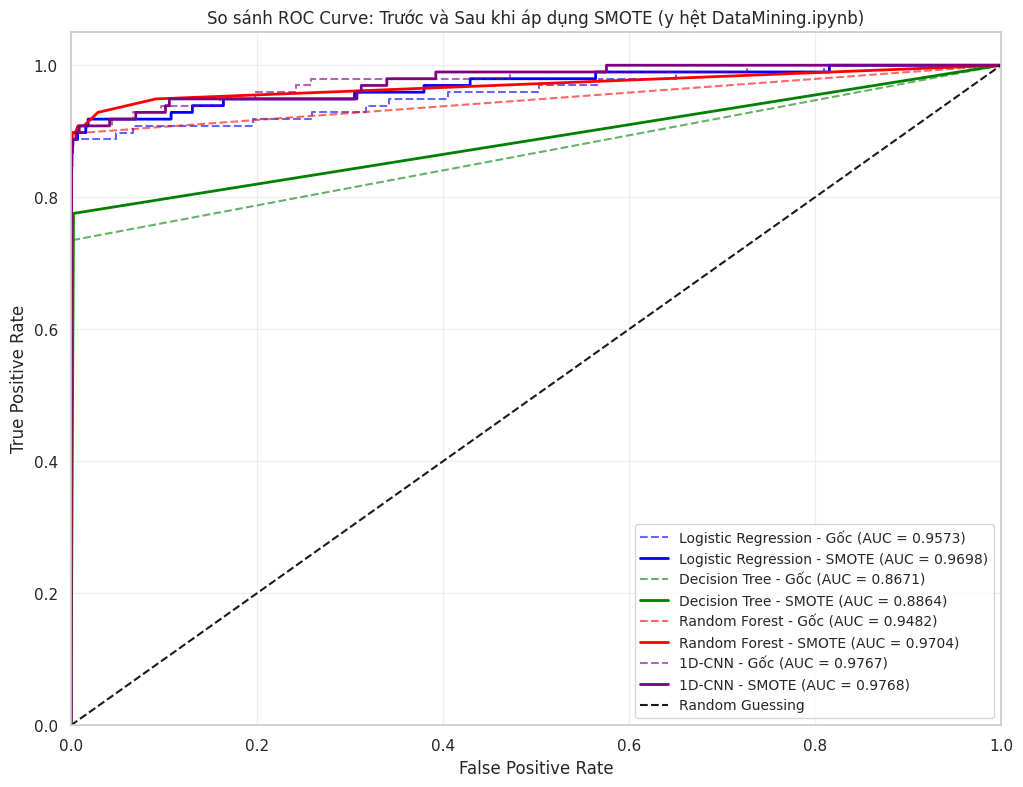

In [10]:
# Vẽ đồ thị ROC Curve so sánh toàn diện 4 mô hình (y hệt DataMining.ipynb)
plt.figure(figsize=(12, 9))

colors = {
    "Logistic Regression": "blue",
    "Decision Tree": "green",
    "Random Forest": "red",
    "1D-CNN": "purple"
}

for name in predictions.keys():
    # --- Xử lý cho mô hình KHÔNG SMOTE ---
    f1_no = f1_score(y_test, predictions_no_smote[name])
    fpr_no, tpr_no, _ = roc_curve(y_test, predict_probas_no_smote[name])
    auc_no = auc(fpr_no, tpr_no)

    print(f"[{name}] F1-Score (Gốc): {f1_no:.4f}  |  F1-Score (SMOTE): {f1_score(y_test, predictions[name]):.4f}")

    plt.plot(fpr_no, tpr_no, color=colors[name], linestyle='--', alpha=0.6,
             label=f'{name} - Gốc (AUC = {auc_no:.4f})')

    # --- Xử lý cho mô hình CÓ SMOTE ---
    fpr_sm, tpr_sm, _ = roc_curve(y_test, predict_probas[name])
    auc_sm = auc(fpr_sm, tpr_sm)

    plt.plot(fpr_sm, tpr_sm, color=colors[name], linestyle='-', linewidth=2,
             label=f'{name} - SMOTE (AUC = {auc_sm:.4f})')

# Cấu hình biểu đồ
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('So sánh ROC Curve: Trước và Sau khi áp dụng SMOTE (y hệt DataMining.ipynb)')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

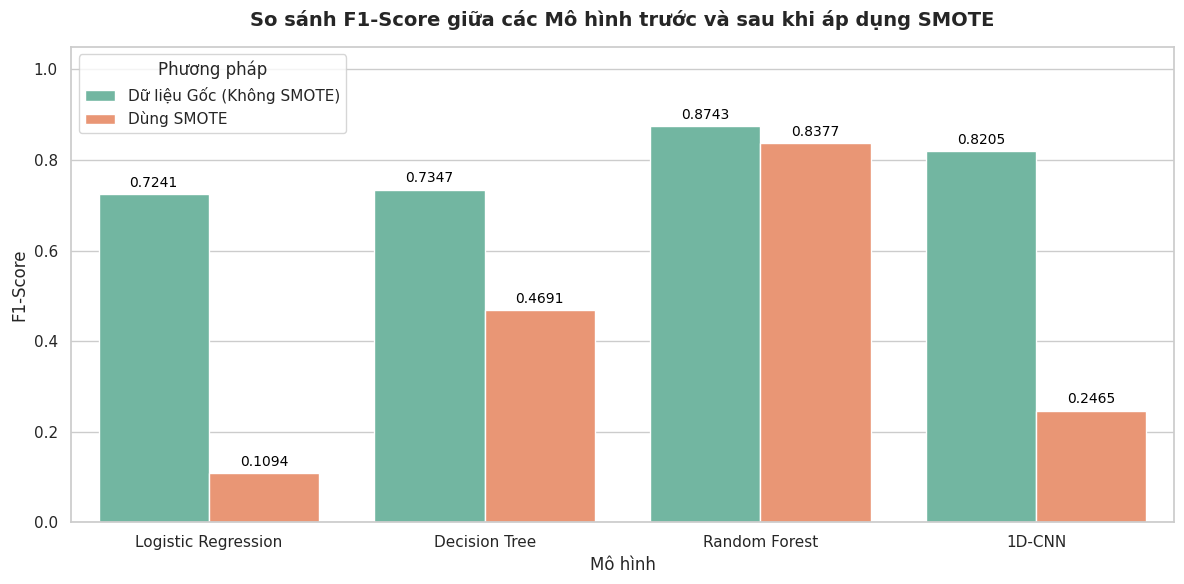

🎉 HOÀN TẤT! Tất cả mô hình học sâu và học máy đã được huấn luyện và lưu thành công.


In [11]:
# Vẽ biểu đồ cột so sánh F1-Score (y hệt DataMining.ipynb)
f1_data = []

for name in predictions.keys():
    # F1 cho tập Gốc
    f1_no = f1_score(y_test, predictions_no_smote[name])
    f1_data.append({'Mô hình': name, 'F1-Score': f1_no, 'Phương pháp': 'Dữ liệu Gốc (Không SMOTE)'})

    # F1 cho tập SMOTE
    f1_sm = f1_score(y_test, predictions[name])
    f1_data.append({'Mô hình': name, 'F1-Score': f1_sm, 'Phương pháp': 'Dùng SMOTE'})

df_metrics = pd.DataFrame(f1_data)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Mô hình', y='F1-Score', hue='Phương pháp', data=df_metrics, palette='Set2')

plt.title('So sánh F1-Score giữa các Mô hình trước và sau khi áp dụng SMOTE', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mô hình', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim([0.0, 1.05])

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.4f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, color='black',
                    xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()
print("🎉 HOÀN TẤT! Tất cả mô hình học sâu và học máy đã được huấn luyện và lưu thành công.")